In [55]:
import re
import pandas as pd

# Load dataset
s22 = pd.read_csv('galaxy_s22_only.csv')

# Step 1: Remove rows with '|' (multiple model options)
s22 = s22[~s22['Title'].str.contains(r'\|', regex=True, na=False)]

# Step 2: Remove titles that list multiple models like "S22 / S22+" or "S22 - S22 Ultra"
pattern_multi = r'\bS?22\b\s*[-/|]\s*\bS?22\s*(?:Ultra|\+|Plus)?\b'
s22 = s22[~s22['Title'].str.contains(pattern_multi, flags=re.IGNORECASE, na=False)]

# ✅ Step 3: Keep only base "Samsung Galaxy S22" — exclude S22+, Plus, Ultra, FE, etc.
s22 = s22[
    # Match "S22" but NOT followed by +, Plus, Ultra, etc.
    s22['Title'].str.contains(r'\b(Samsung\s*)?(Galaxy\s*)?S22(?!\s*(\+|Plus|Ultra|FE|Fan|Pro))\b',
                              flags=re.IGNORECASE, na=False)
]

# Optional: remove duplicates
s22 = s22.drop_duplicates(subset='Title', keep='first')

# Preview results
s22


/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/2829271716.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s22['Title'].str.contains(r'\b(Samsung\s*)?(Galaxy\s*)?S22(?!\s*(\+|Plus|Ultra|FE|Fan|Pro))\b',


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S22
1,1,Samsung Galaxy S22 S901 128GB Unlocked - Excel...,$168.95,2025-10-29,https://www.ebay.com/itm/364498823740,https://i.ebayimg.com/images/g/IzAAAOSwNXFlFYb...,128 GB,Excellent,False,Galaxy S22,True
6,1,Samsung Galaxy S22 S901 128GB Unlocked - Very ...,$159.95,2025-10-29,https://www.ebay.com/itm/404513869457,https://i.ebayimg.com/images/g/u-AAAOSw46tlFYb...,128 GB,Very Good,False,Galaxy S22,True
7,1,Samsung Galaxy S22 5G S901U Unlocked (Any Carr...,$158.99,2025-10-28,https://www.ebay.com/itm/225935482577,https://i.ebayimg.com/images/g/Xp4AAOSwJ4ZjBY2...,Unknown,Very Good,False,Galaxy S22,True
11,1,Samsung Galaxy S22 128GB 256GB S901U Unlocked ...,$144.99,2025-10-28,https://www.ebay.com/itm/157315789642,https://i.ebayimg.com/images/g/xiQAAeSwdaVo3UH...,128 GB,Good,False,Galaxy S22,True
13,1,Samsung Galaxy S22 SM-S901U Unlocked 128GB Pha...,$147.99,2025-10-28,https://www.ebay.com/itm/196518586989,https://i.ebayimg.com/images/g/urQAAOSw2QFmn95...,128 GB,Good,False,Galaxy S22,True
...,...,...,...,...,...,...,...,...,...,...,...
275,3,Samsung Galaxy S22 (5G) - 128GB Pink *UNLOCKED...,$170.99,2025-08-17,https://www.ebay.com/itm/145612601351,https://i.ebayimg.com/images/g/gqIAAOSw6MVlvo-...,128 GB,Very Good,False,Galaxy S22,True
281,3,"Samsung Galaxy S22 5G 128GB 6.1"" Smartphone - ...",$228.00,2025-08-08,https://www.ebay.com/itm/226501317571,https://i.ebayimg.com/images/g/0f8AAOSwHPtnYc2...,128 GB,Excellent,False,Galaxy S22,True
282,3,Samsung Galaxy S22 5G Phantom Black 128GB Unlo...,$149.99,2025-08-07,https://www.ebay.com/itm/277258595879,https://i.ebayimg.com/images/g/TZsAAeSwfQdobRx...,128 GB,Good,False,Galaxy S22,True
285,3,Samsung Galaxy S22 5G SM-S901U - 128GB - Bora ...,$163.15,2025-08-05,https://www.ebay.com/itm/306369728645,https://i.ebayimg.com/images/g/Ur0AAOSwLmFoVmf...,128 GB,Good,False,Galaxy S22,True


In [56]:
import re
import pandas as pd

# Load the dataset
s23 = pd.read_csv('galaxy_s23_only.csv')

# 1) Drop listings that advertise multiple models in one title (contain a pipe)
s23 = s23[~s23['Title'].str.contains(r'\|', regex=True, na=False)]

# 2) Drop titles that explicitly list multiple S23 variants like "S23 / S23 Ultra" or "S23 - S23+"
pattern_multi = r'\bS?23\b\s*[-/|]\s*\bS?23\s*(?:Ultra|\+|Plus|FE|Fan\s*Edition|Pro)?\b'
s23 = s23[~s23['Title'].str.contains(pattern_multi, flags=re.IGNORECASE, na=False)]

# 3) Keep ONLY the base "Samsung Galaxy S23" (allow "S23 5G", etc.)
#    Use negative lookahead so we don't match S23 when followed by +/Plus/Ultra/FE/Fan/Pro
base_s23_only = r'\b(Samsung\s*)?(Galaxy\s*)?S23(?!\s*(\+|Plus|Ultra|FE|Fan\s*Edition|Fan|Pro))\b'
s23 = s23[s23['Title'].str.contains(base_s23_only, flags=re.IGNORECASE, na=False)]

# 4) Exclude refurbished / renewed / used condition keywords
cond_exclude = r'\b(refurb|renewed?|re[-\s]?conditioned|certified\s*refurbished|used|pre[-\s]?owned|open\s*box)\b'
s23 = s23[~s23['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]

# 5) Optional: remove duplicate titles
s23 = s23.drop_duplicates(subset='Title', keep='first')

# Quick preview
s23


/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/3074321006.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s23 = s23[s23['Title'].str.contains(base_s23_only, flags=re.IGNORECASE, na=False)]
/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/3074321006.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s23 = s23[~s23['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S23
0,1,Excellent Samsung Galaxy S23 128GB Cream Veriz...,$234.89,2025-10-29,https://www.ebay.com/itm/187631441629,https://i.ebayimg.com/images/g/tKoAAeSwDdRoeQA...,128 GB,Excellent,False,Galaxy S23,True
1,1,Samsung Galaxy S23 128GB S911U Unlocked - Exce...,$232.99,2025-10-29,https://www.ebay.com/itm/256372271129,https://i.ebayimg.com/images/g/AXAAAeSwl3loL2c...,128 GB,Excellent,False,Galaxy S23,True
4,1,Samsung Galaxy S23 SM-S911U1 5G 128GB Lavende...,$219.00,2025-10-29,https://www.ebay.com/itm/127446681069,https://i.ebayimg.com/images/g/VrMAAeSwaLpo-P1...,128 GB,Unknown,False,Galaxy S23,True
5,1,Samsung Galaxy S23 5G 128/256GB Unlocked -Ref...,$259.99,2025-10-29,https://www.ebay.com/itm/326722087811,https://i.ebayimg.com/images/g/0tsAAOSwAPhl81i...,256 GB,Excellent,False,Galaxy S23,True
12,1,Samsung Galaxy S23 128GB S911U Unlocked - Good,$205.99,2025-10-28,https://www.ebay.com/itm/256372465052,https://i.ebayimg.com/images/g/kvwAAeSwDeVoL2F...,128 GB,Good,False,Galaxy S23,True
...,...,...,...,...,...,...,...,...,...,...,...
327,3,Samsung Galaxy S23 SM-S911U1 - 128GB Green FA...,$254.00,2025-08-22,https://www.ebay.com/itm/116740479169,https://i.ebayimg.com/images/g/Qv0AAeSwMZVoo1t...,128 GB,Unknown,False,Galaxy S23,True
328,3,Samsung Galaxy S23 SM-S911U1 128GB 5G Black F...,$234.00,2025-08-22,https://www.ebay.com/itm/146780539176,https://i.ebayimg.com/images/g/A50AAeSwRAtoo9k...,128 GB,Unknown,False,Galaxy S23,True
330,3,Samsung Galaxy S23 - 128 GB - Lavender - Unloc...,$254.00,2025-08-21,https://www.ebay.com/itm/127096215233,https://i.ebayimg.com/images/g/61cAAOSwNI9kR7a...,128 GB,Excellent,False,Galaxy S23,True
334,3,Samsung Galaxy S23 128GB Phantom Black Unlocke...,$259.99,2025-08-17,https://www.ebay.com/itm/285200013270,https://i.ebayimg.com/images/g/BpYAAOSw1pxlAzw...,128 GB,Very Good,False,Galaxy S23,True


In [57]:
import re
import pandas as pd

# Load the dataset
s24 = pd.read_csv('galaxy_s24_only.csv')

# 1) Remove rows with '|' (multiple model options)
s24 = s24[~s24['Title'].str.contains(r'\|', regex=True, na=False)]

# 2) Remove titles that list multiple models like "S24 / S24 Ultra" or "S24 - S24+"
pattern_multi = r'\bS?24\b\s*[-/|]\s*\bS?24\s*(?:Ultra|\+|Plus|FE|Fan\s*Edition|Pro)?\b'
s24 = s24[~s24['Title'].str.contains(pattern_multi, flags=re.IGNORECASE, na=False)]

# 3) Keep only base "Samsung Galaxy S24" (allow variants like "S24 5G")
#    Negative lookahead ensures we don't match S24 when followed by +, Plus, Ultra, FE, Fan, or Pro
base_s24_only = r'\b(Samsung\s*)?(Galaxy\s*)?S24(?!\s*(\+|Plus|Ultra|FE|Fan\s*Edition|Fan|Pro))\b'
s24 = s24[s24['Title'].str.contains(base_s24_only, flags=re.IGNORECASE, na=False)]

# 4) Exclude refurbished / renewed / used condition keywords
cond_exclude = r'\b(refurb|renewed?|re[-\s]?conditioned|certified\s*refurbished|used|pre[-\s]?owned|open\s*box)\b'
s24 = s24[~s24['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]

# 5) Optional: remove duplicates
s24 = s24.drop_duplicates(subset='Title', keep='first')

# Preview the results
s24


/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/3536121589.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s24 = s24[s24['Title'].str.contains(base_s24_only, flags=re.IGNORECASE, na=False)]
/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/3536121589.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s24 = s24[~s24['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S24
0,1,Samsung Galaxy S24 128GB S921U Unlocked - Very...,$317.99,2025-10-29,https://www.ebay.com/itm/256611130330,https://i.ebayimg.com/images/g/6wYAAeSw6ENoL7q...,128 GB,Very Good,False,Galaxy S24,True
5,1,Samsung Galaxy S24 SM-S921U1 5G 256GB violet ...,$319.00,2025-10-28,https://www.ebay.com/itm/146893972054,https://i.ebayimg.com/images/g/KtoAAeSwVlNo7XQ...,256 GB,Unknown,False,Galaxy S24,True
6,1,Samsung Galaxy S24 SM-S921U1 5G 128GB Violet P...,$304.00,2025-10-28,https://www.ebay.com/itm/116849789783,https://i.ebayimg.com/images/g/WiIAAeSw79Jo2ZL...,128 GB,Unknown,False,Galaxy S24,True
9,1,Samsung Galaxy S24 128GB S921U Unlocked - Exce...,$335.99,2025-10-28,https://www.ebay.com/itm/256496745168,https://i.ebayimg.com/images/g/x8MAAeSwR8toMMG...,128 GB,Excellent,False,Galaxy S24,True
15,1,"Samsung Galaxy S24 5G 128GB 6.2"" Smartphone - ...",$382.00,2025-10-28,https://www.ebay.com/itm/326459470881,https://i.ebayimg.com/images/g/GqIAAOSweypnfbK...,128 GB,Excellent,False,Galaxy S24,True
...,...,...,...,...,...,...,...,...,...,...,...
405,3,Samsung Galaxy S24 128GB SM-S921U1 Black 5G ...,$329.00,2025-08-24,https://www.ebay.com/itm/146780020434,https://i.ebayimg.com/images/g/QP8AAeSw1opoo1t...,128 GB,Unknown,False,Galaxy S24,True
412,3,Samsung Galaxy S24 128GB - Onyx Black Unlocked...,$369.00,2025-08-21,https://www.ebay.com/itm/226156376715,https://i.ebayimg.com/images/g/9hQAAeSwb6pob-h...,128 GB,Unknown,False,Galaxy S24,True
415,3,CERTIFIED Samsung Galaxy S24 128GB SM-S921U1 ...,$304.00,2025-08-20,https://www.ebay.com/itm/127318692214,https://i.ebayimg.com/images/g/-Z8AAeSw1iZoc8o...,128 GB,Unknown,False,Galaxy S24,True
416,3,Samsung Galaxy S24 128GB SM-S921U1 YELLOW 5...,$319.00,2025-08-21,https://www.ebay.com/itm/146756287119,https://i.ebayimg.com/images/g/X3EAAeSw5gxok41...,128 GB,Unknown,False,Galaxy S24,True


In [58]:
import re
import pandas as pd

# Load the dataset
s25 = pd.read_csv('galaxy_s25_only.csv')

# 1) Remove rows with '|' (multiple model options)
s25 = s25[~s25['Title'].str.contains(r'\|', regex=True, na=False)]

# 2) Remove titles that list multiple models like "S25 / S25+" or "S25 - S25 Ultra"
pattern_multi = r'\bS?25\b\s*[-/|]\s*\bS?25\s*(?:Ultra|\+|Plus|FE|Fan\s*Edition|Pro)?\b'
s25 = s25[~s25['Title'].str.contains(pattern_multi, flags=re.IGNORECASE, na=False)]

# 3) Keep ONLY the base "Samsung Galaxy S25"
#    Negative lookahead ensures it doesn't capture Plus, Ultra, etc.
base_s25_only = r'\b(Samsung\s*)?(Galaxy\s*)?S25(?!\s*(\+|Plus|Ultra|FE|Fan\s*Edition|Fan|Pro))\b'
s25 = s25[s25['Title'].str.contains(base_s25_only, flags=re.IGNORECASE, na=False)]

# 4) Exclude refurbished / renewed / used condition keywords
cond_exclude = r'\b(refurb|renewed?|re[-\s]?conditioned|certified\s*refurbished|used|pre[-\s]?owned|open\s*box)\b'
s25 = s25[~s25['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]

# 5) Optional: remove duplicates
s25 = s25.drop_duplicates(subset='Title', keep='first')

# Preview results
s25


/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/264660102.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s25 = s25[s25['Title'].str.contains(base_s25_only, flags=re.IGNORECASE, na=False)]
/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/264660102.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s25 = s25[~s25['Title'].str.contains(cond_exclude, flags=re.IGNORECASE, na=False)]


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S25
1,1,Samsung Galaxy S25 5G - SM-S931U - Unlocked - ...,$463.99,2025-10-28,https://www.ebay.com/itm/146862403064,https://i.ebayimg.com/images/g/lYUAAeSwi-do2sy...,128 GB,Excellent,False,Galaxy S25,True
2,1,Samsung Galaxy S25 Edge 256GB Titanium Silver ...,$599.99,2025-10-28,https://www.ebay.com/itm/277338151823,https://i.ebayimg.com/images/g/jVYAAeSwPJRo-nF...,256 GB,Excellent,False,Galaxy S25,True
5,1,Samsung Galaxy S25 SM-S931U1 128GB Unlocked Ex...,$499.99,2025-10-28,https://www.ebay.com/itm/376644158819,https://i.ebayimg.com/images/g/DzsAAeSwWyNo8Su...,128 GB,Excellent,False,Galaxy S25,True
6,1,Samsung Galaxy S25 Edge 512GB Titanium Silver ...,$629.99,2025-10-28,https://www.ebay.com/itm/277290482816,https://i.ebayimg.com/images/g/jZgAAeSw1kFo-nD...,512 GB,Excellent,False,Galaxy S25,True
9,1,Samsung Galaxy S25 - 128 GB - SM-S931U1 Navy (...,$434.95,2025-10-27,https://www.ebay.com/itm/405977447569,https://i.ebayimg.com/images/g/wm4AAOSwiqBoUuj...,128 GB,Excellent,False,Galaxy S25,True
...,...,...,...,...,...,...,...,...,...,...,...
199,2,Samsung Galaxy S25 (5G) SM-S931U - Unlocked - ...,$509.00,2025-08-08,https://www.ebay.com/itm/146756822773,https://i.ebayimg.com/images/g/oXMAAeSwP4tok5Z...,256 GB,Excellent,False,Galaxy S25,True
200,2,Samsung Galaxy S25 - Unlocked - Silver Shadow ...,$574.00,2025-08-08,https://www.ebay.com/itm/277054239737,https://i.ebayimg.com/images/g/vJAAAeSwvZdo71h...,256 GB,Excellent,False,Galaxy S25,True
201,2,Samsung Galaxy S25 - 128 GB - SM-S931U1 Icyblu...,$484.99,2025-08-08,https://www.ebay.com/itm/127261821539,https://i.ebayimg.com/images/g/~FwAAeSw8n1ogom...,128 GB,Excellent,False,Galaxy S25,True
203,2,Samsung Galaxy S25 Edge Silver 512GB Unlocked ...,$749.99,2025-08-05,https://www.ebay.com/itm/297455815815,https://i.ebayimg.com/images/g/eJUAAeSw1AxobBY...,512 GB,Excellent,False,Galaxy S25,True


In [59]:


# # Combine all cleaned DataFrames above 
# combined_s = pd.concat([s22, s23, s24, s25], ignore_index=True)

# # Save to a new CSV
# combined_s.to_csv('Combined_Samsung_S.csv', index=False)

In [60]:
import pandas as pd

# 1. Combine all cleaned DataFrames
combined_s = pd.concat([s22, s23, s24, s25], ignore_index=True)

# 2. Clean "Sold Date" column
# The CSVs already have dates in YYYY-MM-DD format, so we just convert to datetime
combined_s['Sold Date'] = pd.to_datetime(combined_s['Sold Date'], errors='coerce')

# 3. (Optional) Add year / month columns
combined_s['year'] = combined_s['Sold Date'].dt.year
combined_s['Month'] = combined_s['Sold Date'].dt.month

# 4. Clean price
combined_s['Price_num'] = (
    combined_s['Price']
        .str.replace('[\$,]', '', regex=True)
        .astype(float)
)

# 5. Save cleaned version
combined_s.to_csv('Combined_Samsung_S_clean.csv', index=False)

<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
/var/folders/g_/07970pkx1s139mt1t4qm27080000gn/T/ipykernel_77037/2876593704.py:17: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)


In [61]:
data = pd.read_csv('Combined_Samsung_S_clean.csv')


# Create a regex pattern for +, plus, FE
pattern = r'\+|plus|FE'

# Keep rows where NONE of the columns contain the pattern
data = data[~data.apply(lambda row: row.astype(str).str.contains(pattern, case=False, regex=True).any(), axis=1)]

data['Sold Date'] = pd.to_datetime(data['Sold Date'])
data['year']= data['Sold Date'].dt.year
data['Month'] = data['Sold Date'].dt.month
data['Price_num'] = data['Price'].str.replace('$', '').str.replace(',', '').astype(float)
data


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S22,Galaxy_S23,Galaxy_S24,Galaxy_S25,year,Month,Price_num
0,1,Samsung Galaxy S22 S901 128GB Unlocked - Excel...,$168.95,2025-10-29,https://www.ebay.com/itm/364498823740,https://i.ebayimg.com/images/g/IzAAAOSwNXFlFYb...,128 GB,Excellent,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,168.95
1,1,Samsung Galaxy S22 S901 128GB Unlocked - Very ...,$159.95,2025-10-29,https://www.ebay.com/itm/404513869457,https://i.ebayimg.com/images/g/u-AAAOSw46tlFYb...,128 GB,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,159.95
2,1,Samsung Galaxy S22 5G S901U Unlocked (Any Carr...,$158.99,2025-10-28,https://www.ebay.com/itm/225935482577,https://i.ebayimg.com/images/g/Xp4AAOSwJ4ZjBY2...,Unknown,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,158.99
3,1,Samsung Galaxy S22 128GB 256GB S901U Unlocked ...,$144.99,2025-10-28,https://www.ebay.com/itm/157315789642,https://i.ebayimg.com/images/g/xiQAAeSwdaVo3UH...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,144.99
4,1,Samsung Galaxy S22 SM-S901U Unlocked 128GB Pha...,$147.99,2025-10-28,https://www.ebay.com/itm/196518586989,https://i.ebayimg.com/images/g/urQAAOSw2QFmn95...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,147.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2,Samsung Galaxy S25 (5G) SM-S931U - Unlocked - ...,$509.00,2025-08-08,https://www.ebay.com/itm/146756822773,https://i.ebayimg.com/images/g/oXMAAeSwP4tok5Z...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,509.00
531,2,Samsung Galaxy S25 - Unlocked - Silver Shadow ...,$574.00,2025-08-08,https://www.ebay.com/itm/277054239737,https://i.ebayimg.com/images/g/vJAAAeSwvZdo71h...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,574.00
532,2,Samsung Galaxy S25 - 128 GB - SM-S931U1 Icyblu...,$484.99,2025-08-08,https://www.ebay.com/itm/127261821539,https://i.ebayimg.com/images/g/~FwAAeSw8n1ogom...,128 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,484.99
533,2,Samsung Galaxy S25 Edge Silver 512GB Unlocked ...,$749.99,2025-08-05,https://www.ebay.com/itm/297455815815,https://i.ebayimg.com/images/g/eJUAAeSw1AxobBY...,512 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,749.99


In [62]:
data['Release Date'] = data['Model'].replace({
    "Galaxy S22": "2022-02",
    "Galaxy S23": "2023-02",
    "Galaxy S24": "2024-01",
    "Galaxy S25": "2025-01",
    # Fallback for older naming if needed
    "Samsung Galaxy S22": "2022-02",
    "Samsung Galaxy S23": "2023-02",
    "Samsung Galaxy S24": "2024-01",
    "Samsung Galaxy S25": "2025-01"
})

#make it month
data["Age_at_Sale"] = (data['Sold Date'] - pd.to_datetime(data['Release Date'])).dt.days / 30.44  # Approximate months
data["Age_at_Sale"] = data["Age_at_Sale"].round(2)
data

,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S22,Galaxy_S23,Galaxy_S24,Galaxy_S25,year,Month,Price_num,Release Date,Age_at_Sale
0,1,Samsung Galaxy S22 S901 128GB Unlocked - Excel...,$168.95,2025-10-29,https://www.ebay.com/itm/364498823740,https://i.ebayimg.com/images/g/IzAAAOSwNXFlFYb...,128 GB,Excellent,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,168.95,2022-02,44.88
1,1,Samsung Galaxy S22 S901 128GB Unlocked - Very ...,$159.95,2025-10-29,https://www.ebay.com/itm/404513869457,https://i.ebayimg.com/images/g/u-AAAOSw46tlFYb...,128 GB,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,159.95,2022-02,44.88
2,1,Samsung Galaxy S22 5G S901U Unlocked (Any Carr...,$158.99,2025-10-28,https://www.ebay.com/itm/225935482577,https://i.ebayimg.com/images/g/Xp4AAOSwJ4ZjBY2...,Unknown,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,158.99,2022-02,44.84
3,1,Samsung Galaxy S22 128GB 256GB S901U Unlocked ...,$144.99,2025-10-28,https://www.ebay.com/itm/157315789642,https://i.ebayimg.com/images/g/xiQAAeSwdaVo3UH...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,144.99,2022-02,44.84
4,1,Samsung Galaxy S22 SM-S901U Unlocked 128GB Pha...,$147.99,2025-10-28,https://www.ebay.com/itm/196518586989,https://i.ebayimg.com/images/g/urQAAOSw2QFmn95...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,147.99,2022-02,44.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2,Samsung Galaxy S25 (5G) SM-S931U - Unlocked - ...,$509.00,2025-08-08,https://www.ebay.com/itm/146756822773,https://i.ebayimg.com/images/g/oXMAAeSwP4tok5Z...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,509.00,2025-01,7.19
531,2,Samsung Galaxy S25 - Unlocked - Silver Shadow ...,$574.00,2025-08-08,https://www.ebay.com/itm/277054239737,https://i.ebayimg.com/images/g/vJAAAeSwvZdo71h...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,574.00,2025-01,7.19
532,2,Samsung Galaxy S25 - 128 GB - SM-S931U1 Icyblu...,$484.99,2025-08-08,https://www.ebay.com/itm/127261821539,https://i.ebayimg.com/images/g/~FwAAeSw8n1ogom...,128 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,484.99,2025-01,7.19
533,2,Samsung Galaxy S25 Edge Silver 512GB Unlocked ...,$749.99,2025-08-05,https://www.ebay.com/itm/297455815815,https://i.ebayimg.com/images/g/eJUAAeSw1AxobBY...,512 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,749.99,2025-01,7.10


In [63]:
import numpy as np
import pandas as pd

# ensure datetimes first
data["Sold Date"] = pd.to_datetime(data["Sold Date"], errors="coerce")
data["Release Date"] = pd.to_datetime(data["Release Date"], errors="coerce")

# option 1: use a timedelta for ~month length
data["Age_at_Sale"] = (
    (data["Sold Date"] - data["Release Date"]) / pd.Timedelta(days=30.44)
).round(2)

# option 2: divide by days then months
data["Age_at_Sale"] = (
    (data["Sold Date"] - data["Release Date"]) / np.timedelta64(1, "D") / 30.44
).round(2)

data


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S22,Galaxy_S23,Galaxy_S24,Galaxy_S25,year,Month,Price_num,Release Date,Age_at_Sale
0,1,Samsung Galaxy S22 S901 128GB Unlocked - Excel...,$168.95,2025-10-29,https://www.ebay.com/itm/364498823740,https://i.ebayimg.com/images/g/IzAAAOSwNXFlFYb...,128 GB,Excellent,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,168.95,2022-02-01,44.88
1,1,Samsung Galaxy S22 S901 128GB Unlocked - Very ...,$159.95,2025-10-29,https://www.ebay.com/itm/404513869457,https://i.ebayimg.com/images/g/u-AAAOSw46tlFYb...,128 GB,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,159.95,2022-02-01,44.88
2,1,Samsung Galaxy S22 5G S901U Unlocked (Any Carr...,$158.99,2025-10-28,https://www.ebay.com/itm/225935482577,https://i.ebayimg.com/images/g/Xp4AAOSwJ4ZjBY2...,Unknown,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,158.99,2022-02-01,44.84
3,1,Samsung Galaxy S22 128GB 256GB S901U Unlocked ...,$144.99,2025-10-28,https://www.ebay.com/itm/157315789642,https://i.ebayimg.com/images/g/xiQAAeSwdaVo3UH...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,144.99,2022-02-01,44.84
4,1,Samsung Galaxy S22 SM-S901U Unlocked 128GB Pha...,$147.99,2025-10-28,https://www.ebay.com/itm/196518586989,https://i.ebayimg.com/images/g/urQAAOSw2QFmn95...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,147.99,2022-02-01,44.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2,Samsung Galaxy S25 (5G) SM-S931U - Unlocked - ...,$509.00,2025-08-08,https://www.ebay.com/itm/146756822773,https://i.ebayimg.com/images/g/oXMAAeSwP4tok5Z...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,509.00,2025-01-01,7.19
531,2,Samsung Galaxy S25 - Unlocked - Silver Shadow ...,$574.00,2025-08-08,https://www.ebay.com/itm/277054239737,https://i.ebayimg.com/images/g/vJAAAeSwvZdo71h...,256 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,574.00,2025-01-01,7.19
532,2,Samsung Galaxy S25 - 128 GB - SM-S931U1 Icyblu...,$484.99,2025-08-08,https://www.ebay.com/itm/127261821539,https://i.ebayimg.com/images/g/~FwAAeSw8n1ogom...,128 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,484.99,2025-01-01,7.19
533,2,Samsung Galaxy S25 Edge Silver 512GB Unlocked ...,$749.99,2025-08-05,https://www.ebay.com/itm/297455815815,https://i.ebayimg.com/images/g/eJUAAeSw1AxobBY...,512 GB,Excellent,False,Galaxy S25,NaN,NaN,NaN,True,2025,8,749.99,2025-01-01,7.10


In [64]:
import re
import numpy as np
import pandas as pd

# --- Samsung Galaxy S-series launch prices (US MSRP, standard S model) ---

samsung_release_price_map = {
    # Galaxy S22 base: 128GB $799, 256GB $849
    'S22': { '128': 799.0, '256': 849.0 },

    # Galaxy S23 base: 128GB $799, 256GB $859
    'S23': { '128': 799.0, '256': 859.0 },

    # Galaxy S24 base: 128GB $799, 256GB $859
    'S24': { '128': 799.0, '256': 859.0 },

    # Galaxy S25 base: 128GB $799, 256GB $859
    'S25': { '128': 799.0, '256': 859.0 },
}

# --- Storage extractor (reuses your existing logic) ---

def extract_storage_from_row(row):
    # Try common explicit columns first (if they exist)
    for col in ['Storage', 'Capacity', 'Memory', 'Storage Capacity']:
        if col in row.index and pd.notna(row[col]):
            s = str(row[col])
            m = re.search(r'(64|128|256|512)', s)
            if m:
                return m.group(1)

    # Fallback: parse Title (and optionally Model)
    title = str(row.get('Title', ''))
    m = re.search(r'\b(64|128|256|512)\s*(?:GB|G|gb)?\b', title, flags=re.IGNORECASE)
    if m:
        return m.group(1)

    # Try compact forms like '64GB' without space
    m = re.search(r'(64|128|256|512)GB', title, flags=re.IGNORECASE)
    if m:
        return m.group(1)

    return None

# --- Samsung model-key extractor: e.g. "Galaxy S22", "Samsung Galaxy S23 5G", etc. ---

def extract_samsung_model_key(row):
    text = str(row.get('Model', '') or row.get('Title', ''))

    # Match "Galaxy S22", "Samsung Galaxy S23 5G", etc.
    # Captures 22, 23, 24, 25 from any 'Galaxy S(22|23|24|25)' pattern.
    m = re.search(r'galaxy\s*s\s*(22|23|24|25)\b', text, flags=re.IGNORECASE)
    if m:
        num = m.group(1).strip()
        return f'S{num}'   # e.g. "S22"
    return None

# --- Mapper to assign first-release price for Samsung Galaxy S-series ---

def map_samsung_first_release_price(row):
    model_key = extract_samsung_model_key(row)   # e.g. "S23"
    if not model_key:
        return np.nan

    if model_key not in samsung_release_price_map:
        return np.nan

    storage = extract_storage_from_row(row)
    if storage and storage in samsung_release_price_map[model_key]:
        return samsung_release_price_map[model_key][storage]

    return np.nan

# --- Load data if needed (same pattern you used before) ---

if 'data' not in globals():
    try:
        data = pd.read_csv('Samsung_base.csv')  # or whatever your Samsung CSV is called
        if 'Sold Date' in data.columns:
            data['Sold Date'] = pd.to_datetime(data['Sold Date'], errors='coerce')
    except FileNotFoundError:
        raise FileNotFoundError('Samsung_base.csv not found; load your Samsung data into `data`')

# Create/overwrite the column with Samsung launch prices
data['First_Release_Price'] = data.apply(map_samsung_first_release_price, axis=1)

# Quick checks: report filled counts per Samsung S model
for model_key, mapping in samsung_release_price_map.items():
    model_label_pattern = fr'Galaxy\s*S\s*{model_key[1:]}'  # e.g. "Galaxy S 22" / "Galaxy S22"
    mask = data['Model'].str.contains(model_label_pattern, case=False, na=False)
    total = data[mask].shape[0]
    filled = data[mask & data['First_Release_Price'].notna()].shape[0]
    print(f'Galaxy {model_key}: filled {filled} / {total}')

# Show sample rows where price was set
display(data[data['First_Release_Price'].notna()].head())

# Optionally save an updated CSV
# data.to_csv('Samsung_S_with_release_price.csv', index=False)


Galaxy S22: filled 142 / 148
Galaxy S23: filled 129 / 137
Galaxy S24: filled 118 / 122
Galaxy S25: filled 107 / 119


,Page,Title,Price,Sold Date,Link,Image Link,Storage,Condition,PartsOnly,Model,Galaxy_S22,Galaxy_S23,Galaxy_S24,Galaxy_S25,year,Month,Price_num,Release Date,Age_at_Sale,First_Release_Price
0,1,Samsung Galaxy S22 S901 128GB Unlocked - Excel...,$168.95,2025-10-29,https://www.ebay.com/itm/364498823740,https://i.ebayimg.com/images/g/IzAAAOSwNXFlFYb...,128 GB,Excellent,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,168.95,2022-02-01,44.88,799.0
1,1,Samsung Galaxy S22 S901 128GB Unlocked - Very ...,$159.95,2025-10-29,https://www.ebay.com/itm/404513869457,https://i.ebayimg.com/images/g/u-AAAOSw46tlFYb...,128 GB,Very Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,159.95,2022-02-01,44.88,799.0
3,1,Samsung Galaxy S22 128GB 256GB S901U Unlocked ...,$144.99,2025-10-28,https://www.ebay.com/itm/157315789642,https://i.ebayimg.com/images/g/xiQAAeSwdaVo3UH...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,144.99,2022-02-01,44.84,799.0
4,1,Samsung Galaxy S22 SM-S901U Unlocked 128GB Pha...,$147.99,2025-10-28,https://www.ebay.com/itm/196518586989,https://i.ebayimg.com/images/g/urQAAOSw2QFmn95...,128 GB,Good,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,147.99,2022-02-01,44.84,799.0
5,1,Samsung Galaxy S22 128GB S901U Unlocked - Exce...,$177.99,2025-10-28,https://www.ebay.com/itm/255750739980,https://i.ebayimg.com/images/g/eHQAAeSwa6VojEf...,128 GB,Excellent,False,Galaxy S22,True,NaN,NaN,NaN,2025,10,177.99,2022-02-01,44.84,799.0


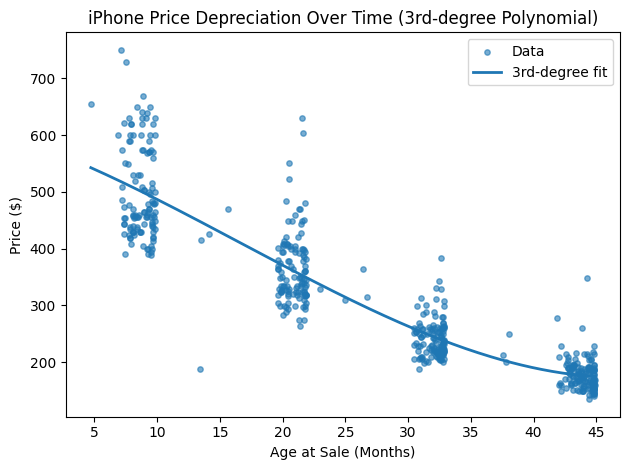

In [65]:
from matplotlib import pyplot as plt
import numpy as np

# Make sure column names are clean
data.rename(columns=str.strip, inplace=True)

# Use clean columns
x = data['Age_at_Sale']          # months
y = data['Price_num']

# Drop NaNs/infs before fitting
m = np.isfinite(x) & np.isfinite(y)
x = x[m].to_numpy()
y = y[m].to_numpy()

# Fit and build 3rd-degree polynomial
degree = 3
coeffs = np.polyfit(x, y, degree)
poly_eq = np.poly1d(coeffs)

# Smooth curve for the fit
x_line = np.linspace(x.min(), x.max(), 200)
y_line = poly_eq(x_line)

# Plot scatter + fitted curve
plt.scatter(x, y, s=15, alpha=0.6, label='Data')
plt.plot(x_line, y_line, linewidth=2, label=f'{degree}rd-degree fit')
plt.xlabel('Age at Sale (Months)')
plt.ylabel('Price ($)')
plt.title('iPhone Price Depreciation Over Time (3rd-degree Polynomial)')
plt.legend()
plt.tight_layout()
plt.show()


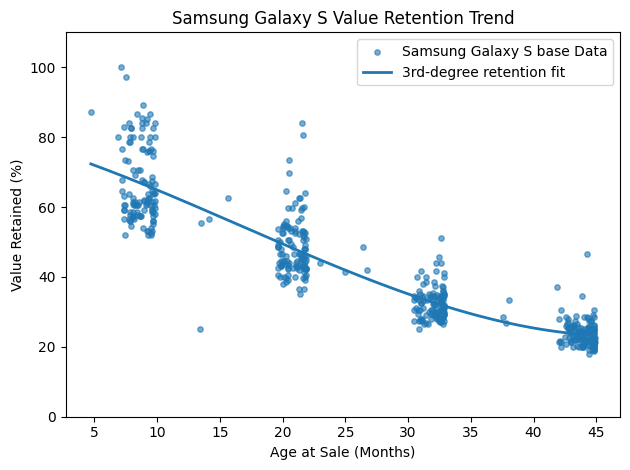

In [66]:
from matplotlib import pyplot as plt
import numpy as np

# Make sure column names are clean
data.rename(columns=str.strip, inplace=True)

# Use clean columns
x = data['Age_at_Sale']          # months
y = data['Price_num']

# Drop NaNs/infs before fitting
m = np.isfinite(x) & np.isfinite(y)
x = x[m].to_numpy()
y = y[m].to_numpy()

# -------------------------------
# Convert price → retention value
# -------------------------------
original_price = y.max()                  # highest observed resale price
retention = (y / original_price) * 100    # retention percentage

# Fit and build 3rd-degree polynomial for retention
degree = 3
coeffs = np.polyfit(x, retention, degree)
poly_eq = np.poly1d(coeffs)

# Smooth curve for the fit
x_line = np.linspace(x.min(), x.max(), 200)
y_line = poly_eq(x_line)

# Plot scatter + fitted curve
plt.scatter(x, retention, s=15, alpha=0.6, label='Samsung Galaxy S base Data')
plt.plot(x_line, y_line, linewidth=2, label=f'{degree}rd-degree retention fit')

plt.xlabel('Age at Sale (Months)')
plt.ylabel('Value Retained (%)')
plt.title('Samsung Galaxy S Value Retention Trend')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()

import os
# Save figure
os.makedirs('output', exist_ok=True)
plt.savefig('output/samsung_s_value_retention_polynomial_fit.png', dpi=300)


plt.show()


In [67]:
# === Samsung S-series resale regression (S22–S25) ===

import re
import numpy as np
import pandas as pd
import sklearn.linear_model as lm  # Import module with alias to avoid name conflicts
from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# 1) LOAD SAMSUNG DATA
# -----------------------------------------------------------

data = data.rename(columns=str.strip).copy()
data['Sold Date'] = pd.to_datetime(data['Sold Date'], errors='coerce')

# Numeric sold price
data['Price_num'] = (
    data['Price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)

# ------------------------------------------------------------
# 2) RELEASE MONTHS FOR S22–S25
# ------------------------------------------------------------
release_month_map = {
    '22': "2022-02",
    '23': "2023-02",
    '24': "2024-01",
    '25': "2025-02",   # predicted launch cycle same as S24
}

def extract_samsung_model_number(row):
    """Extract S number (22, 23, 24, 25)."""
    text = str(row.get('Model', '') or row.get('Title', ''))
    m = re.search(r'galaxy\s*s\s*(22|23|24|25)\b', text, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    return None

def map_release_month(row):
    model_num = extract_samsung_model_number(row)
    if not model_num:
        return np.nan
    return release_month_map.get(model_num.strip(), np.nan)

data['Release Date'] = data.apply(map_release_month, axis=1)
data['Release Date'] = pd.to_datetime(data['Release Date'], errors='coerce')

# ------------------------------------------------------------
# 3) Samsung Launch Prices
# ------------------------------------------------------------
samsung_launch_price = {
    '22': { '128': 799.0, '256': 849.0 },
    '23': { '128': 799.0, '256': 859.0 },
    '24': { '128': 799.0, '256': 859.0 },
    '25': { '128': 799.0, '256': 859.0 },
}

def extract_storage(row):
    """Extract storage (GB) from Storage, Model, Title."""
    # direct columns first
    for col in ['Storage', 'Capacity', 'Memory', 'Storage Capacity']:
        if col in row.index and pd.notna(row[col]):
            m = re.search(r'(128|256|512|1024)', str(row[col]))
            if m:
                return m.group(1)

    # fallback: parse from full text
    text = str(row.get('Model', '')) + " " + str(row.get('Title', ''))
    m = re.search(r'\b(128|256|512|1024)\s*(gb|g|tb)?\b', text, flags=re.IGNORECASE)
    if m:
        return m.group(1)

    return None

def map_launch_price(row):
    model_num = extract_samsung_model_number(row)
    if not model_num:
        return np.nan
    storage = extract_storage(row)
    if not storage:
        return np.nan
    price_map = samsung_launch_price.get(model_num.strip())
    if not price_map:
        return np.nan
    return price_map.get(storage, np.nan)

data['First_Release_Price'] = data.apply(map_launch_price, axis=1)

# ------------------------------------------------------------
# 4) AGE AT SALE (months)
# ------------------------------------------------------------
data['Age_at_Sale'] = (
    (data['Sold Date'] - data['Release Date']).dt.days / 30.44
)

# ------------------------------------------------------------
# 5) BUILD REGRESSION DATAFRAME
# ------------------------------------------------------------
mask = (
    data['Age_at_Sale'].notna() &
    data['Price_num'].notna() &
    data['First_Release_Price'].notna() &
    (data['First_Release_Price'] > 0)
)

df = data.loc[mask].copy()

# price ratio = sold price / launch price
df['Price_ratio'] = df['Price_num'] / df['First_Release_Price']

# storage numeric
df['Storage_num'] = df.apply(lambda r: float(extract_storage(r) or np.nan), axis=1)

df['Year_of_Sale']  = df['Sold Date'].dt.year
df['Month_of_Sale'] = df['Sold Date'].dt.month

# Clean condition
df['Condition'] = (
    df.get('Condition', pd.Series(index=df.index, dtype=str))
      .astype(str).str.strip().str.title()
)
unknowns = {'Unknown', 'Unspecified', '', 'None', 'Na', 'Nan'}
df.loc[df['Condition'].isin(unknowns), 'Condition'] = np.nan
df = df.dropna(subset=['Condition'])

# One-hot encode condition
enc = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
cond_mat = enc.fit_transform(df[['Condition']])
cond_cols = enc.get_feature_names_out(['Condition'])
cond_df = pd.DataFrame(cond_mat, columns=cond_cols, index=df.index)

# Feature matrix
X_num = df[['Age_at_Sale', 'Storage_num', 'Year_of_Sale', 'Month_of_Sale']]
X = pd.concat([X_num, cond_df], axis=1)
y = df['Price_ratio']

good = X.notna().all(axis=1) & y.notna()
X = X.loc[good]
y = y.loc[good]

# ------------------------------------------------------------
# 6) FIT MODEL
# ------------------------------------------------------------
model = lm.LinearRegression()  # Use the alias
model.fit(X, y)

print("=== Samsung S-series Model Fit ===")
print("Samples:", len(y))
print("Intercept:", model.intercept_)
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.6f}")

# ------------------------------------------------------------
# 7) PREDICTION HELPER
# ------------------------------------------------------------
def predict_samsung_price(age_months, storage_gb, year, month, condition, launch_price):
    base = pd.DataFrame({
        'Age_at_Sale':   [age_months],
        'Storage_num':   [storage_gb],
        'Year_of_Sale':  [year],
        'Month_of_Sale': [month],
        'Condition':     [str(condition).strip().title()]
    })

    cond_new = pd.DataFrame(
        enc.transform(base[['Condition']]),
        columns=cond_cols,
        index=base.index
    )

    X_new = pd.concat([
        base[['Age_at_Sale', 'Storage_num', 'Year_of_Sale', 'Month_of_Sale']],
        cond_new
    ], axis=1)

    # align with model columns
    X_new = X_new.reindex(columns=X.columns, fill_value=0)

    ratio = model.predict(X_new)[0]
    return ratio * float(launch_price)

# Example prediction:
# S24, 256GB, 12 months old, Excellent, selling Jan 2026
# lp = samsung_launch_price['24']['256']
# pred = predict_samsung_price(12, 256, 2026, 1, "Excellent", lp)
# print("Predicted resale:", pred)

=== Samsung S-series Model Fit ===
Samples: 323
Intercept: -235.01548684014813
Age_at_Sale: -0.010452
Storage_num: 0.000335
Year_of_Sale: 0.116357
Month_of_Sale: 0.000851
Condition_Excellent: 0.024076
Condition_Good: -0.023809
Condition_Very Good: -0.000267
